# Minimal Encoder -> ODE -> Decoder Demo

Uses `results/separate_multisine_05_20260318_095907` with the aligned `multisine_05` true-label CSV.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import BabVideoPipelineConfig
from src.data.registry import ensure_true_labels
from src.models.base import load_model, resolve_device
from src.vision.datasets import FrameStateDataset, load_bab_with_video
from src.vision.models import DecoderFrameDeconv, EncOdeDecModel, EncoderThetaNet

/home/hpc/dsaa/dsaa110h/projects/hybrid_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
run_dir = ROOT / "results/separate_multisine_05_20260318_095907"
cfg = BabVideoPipelineConfig.from_dict(json.loads((run_dir / "config.json").read_text()))
assert cfg.encoder == "theta_regression" and cfg.encoder_velocity_mode == "full_encoder"

true_csv = str(ensure_true_labels(cfg.dataset))
data, frames, frame_idx_map, aux = load_bab_with_video(
    cfg.dataset,
    video_dir=cfg.video_dir,
    video_path=cfg.video_path,
    resample_factor=cfg.resample_factor,
    video_fps=cfg.video_fps,
    frame_height=cfg.frame_height,
    frame_width=cfg.frame_width,
    preprocess=True,
    led_frame=cfg.led_frame,
    use_led_sync=cfg.use_led_sync,
    keypoint_labels_csv=true_csv,
    theta_labels_csv=true_csv,
    align_theta=cfg.align_theta,
    alignment_offset_min_s=cfg.alignment_offset_min_s,
    alignment_offset_max_s=cfg.alignment_offset_max_s,
    auto_match_video_fps=cfg.auto_match_video_fps,
    return_aux=True,
)

device = resolve_device(cfg.device)
encoder = EncoderThetaNet(pretrained=False, state_dim=2, in_channels=6).to(device).eval()
encoder.load_state_dict(torch.load(run_dir / "encoder_best.pt", map_location=device))
decoder = DecoderFrameDeconv(frame_height=cfg.frame_height, frame_width=cfg.frame_width).to(device).eval()
decoder.load_state_dict(torch.load(run_dir / "decoder_image_best.pt", map_location=device))
model = EncOdeDecModel(encoder, load_model(run_dir / "ode_model.pt").ode_func_, decoder, dt=1 / data.sampling_rate, encoder_velocity_mode=cfg.encoder_velocity_mode).to(device).eval()
frame_ds = FrameStateDataset(data, frames, frame_idx_map, encoder_velocity_mode=cfg.encoder_velocity_mode)

print(run_dir.name, "| samples:", len(data), "| frames:", len(frames), "| device:", device)
print("theta alignment:", aux.get("theta_alignment"))

separate_multisine_05_20260318_095907 | samples: 1667 | frames: 4431 | device: cpu
theta alignment: {'offset_s': 0.0, 'sign': 1, 'alpha': -0.7151855976890341, 'beta': -0.33250046165982994, 'corr': 0.959512984244907, 'rmse': 0.31042233586511453}


In [19]:
theta_dot = data.y_dot if data.y_dot is not None else np.gradient(data.y, 1 / data.sampling_rate)
i = int(np.nanargmax(np.abs(theta_dot[:-3])))
rollout_steps = 200
x_in, x0_true, meta = frame_ds[i]
frame_ids = frame_idx_map[i : i + rollout_steps]
prev_frame, curr_frame = frames[meta["frame_idx_prev"]], frames[meta["frame_idx"]]
u = torch.tensor(np.asarray(data.u[i : i + rollout_steps], dtype=np.float32).reshape(-1, 1), device=device)

with torch.no_grad():
    x0_hat = encoder(x_in.unsqueeze(0).to(device))
    x_seq = model.rollout(x0_hat, u, rollout_steps)
    pred_frames = model.decode(x_seq)[:, 0].cpu().permute(0, 2, 3, 1).numpy()

pred_states = x_seq[:, 0].cpu().numpy()
true_states = np.c_[data.y[i : i + rollout_steps], theta_dot[i : i + rollout_steps]]

print("full_encoder input = [current frame, current - previous frame]")
print("t =", round(float(data.t[i]), 3), "s | x0_hat =", x0_hat.cpu().numpy().round(3), "| x0_true =", x0_true.numpy().round(3))
print("pred states:\n", pred_states.round(3))
print("true states:\n", true_states.round(3))

[W318 17:12:43.551813301 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.609408277 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.625577909 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.664281507 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.678170489 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.715182773 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.728522181 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.783261080 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.835793250 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:12:43.853710426 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W318 17:1

full_encoder input = [current frame, current - previous frame]
t = 40.489 s | x0_hat = [[ 1.036 37.336]] | x0_true = [ 0.669 46.168]
pred states:
 [[ 1.0360e+00  3.7336e+01]
 [ 2.2680e+00  2.4158e+01]
 [ 3.0650e+00  9.6280e+00]
 [ 3.3830e+00 -6.4900e+00]
 [ 3.1690e+00 -1.7347e+01]
 [ 2.5960e+00 -2.1532e+01]
 [ 1.8860e+00 -2.4682e+01]
 [ 1.0710e+00 -2.5025e+01]
 [ 2.4500e-01 -2.3520e+01]
 [-5.3100e-01 -1.8809e+01]
 [-1.1510e+00 -1.2023e+01]
 [-1.5480e+00 -7.6400e+00]
 [-1.8000e+00 -1.7770e+00]
 [-1.8590e+00  2.3140e+00]
 [-1.7820e+00  6.2580e+00]
 [-1.5760e+00  9.2280e+00]
 [-1.2710e+00  1.1410e+01]
 [-8.9500e-01  1.2856e+01]
 [-4.7100e-01  1.2901e+01]
 [-4.5000e-02  1.0402e+01]
 [ 2.9800e-01  5.7680e+00]
 [ 4.8900e-01  2.0050e+00]
 [ 5.5500e-01 -2.4310e+00]
 [ 4.7500e-01 -4.9290e+00]
 [ 3.1200e-01 -6.0790e+00]
 [ 1.1100e-01 -6.7270e+00]
 [-1.1100e-01 -5.8640e+00]
 [-3.0400e-01 -3.7310e+00]
 [-4.2700e-01 -3.8400e-01]
 [-4.4000e-01  2.7950e+00]
 [-3.4800e-01  5.9850e+00]
 [-1.5000e-01  9

In [39]:
t_index = [0, 45, 90, 140]

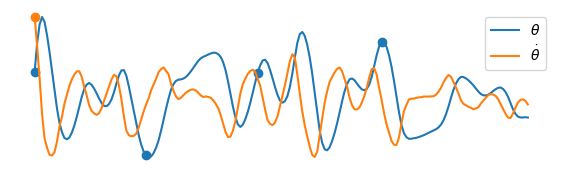

In [45]:
fig, ax = plt.subplots(figsize=(7, 2))
ts = data.t[i : i + rollout_steps] - data.t[i]
ax.plot(ts, pred_states[:, 0], color="C0", label="$\\theta$")
#ax.plot(ts, true_states[:, 0], color="C0", linestyle="dashed")
# twin_ax = ax.twinx()
ax2 = ax.twinx()
ax2.plot(ts, pred_states[:, 1], color="C1", label="$\\dot{\\theta}$")
ax2.plot(0, pred_states[0, 1], 'o', color="C1", zorder=5)
#ax2.plot(ts, true_states[:, 1], color="C1", linestyle="dashed")

for i, t in enumerate(t_index):
    ax.plot(ts[t], pred_states[t, 0], 'o', color="C0", zorder=5)

for a in [ax, ax2]:
    for spine in a.spines.values():
        spine.set_visible(False)
    a.set_xticks([])
    a.set_yticks([])

#legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

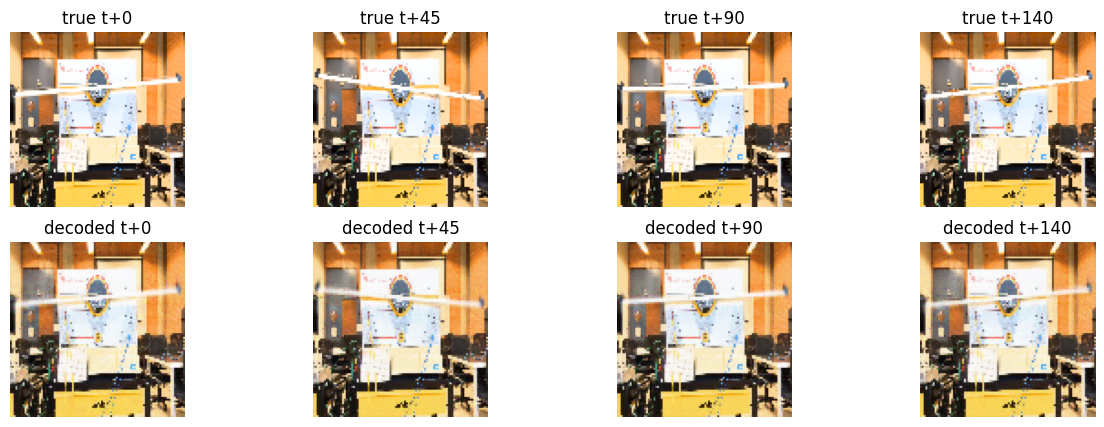

In [43]:
fig, ax = plt.subplots(2, len(t_index), figsize=(15, 5))
for k, t in enumerate(t_index):
    ax[0, k].imshow(frames[frame_ids[t]]); ax[0, k].set_title(f"true t+{t}"); ax[0, k].axis("off")
    ax[1, k].imshow(np.clip(pred_frames[t], 0, 1)); ax[1, k].set_title(f"decoded t+{t}"); ax[1, k].axis("off")

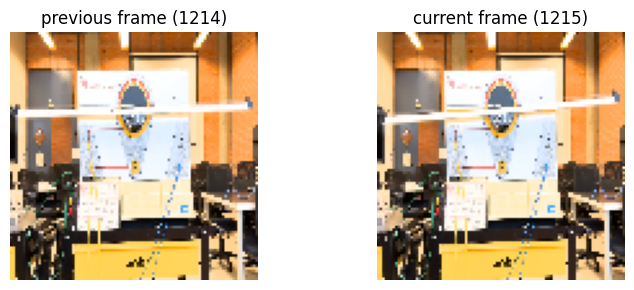

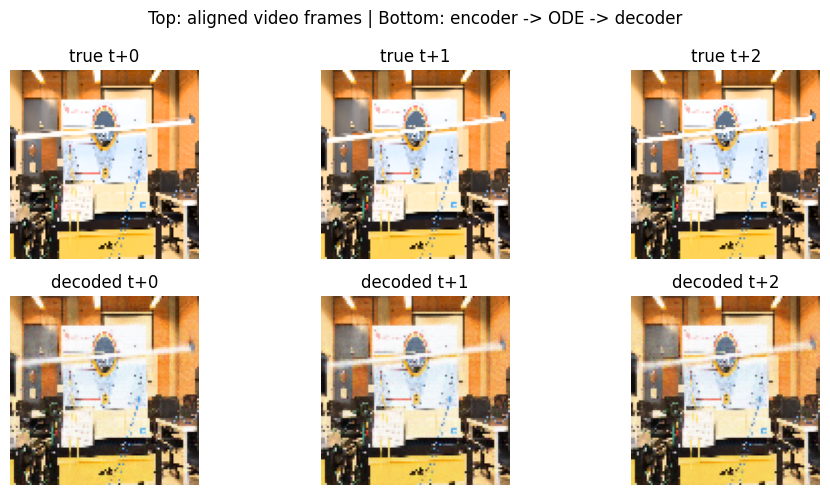

In [5]:

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
for a, img, title in zip(ax, [prev_frame, curr_frame], [f"previous frame ({meta['frame_idx_prev']})", f"current frame ({meta['frame_idx']})"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, 3, figsize=(10, 5))
for k in range(3):
    ax[0, k].imshow(frames[frame_ids[k]]); ax[0, k].set_title(f"true t+{k}"); ax[0, k].axis("off")
    ax[1, k].imshow(np.clip(pred_frames[k], 0, 1)); ax[1, k].set_title(f"decoded t+{k}"); ax[1, k].axis("off")
fig.suptitle("Top: aligned video frames | Bottom: encoder -> ODE -> decoder", y=0.98)
plt.tight_layout(); plt.show()